# RAG QA Logs — Ops, Risk, and Trade-offs

This notebook turns **multi-table RAG telemetry** into **decision-grade ops signals** you can act on.

You will analyze the system end-to-end — from **corpus/chunks** to **retrieval events** to **QA eval runs** — and answer four production questions:

- **Failure attribution:** is the miss coming from **retrieval** (coverage/recall) or **generation** (faithfulness/answer quality)?
- **Risk concentration:** which slices are fragile across **domain**, **scenario type**, and **difficulty**?
- **Config selection:** which **retrieval + model** setup dominates when you trade **quality vs cost vs latency**?
- **Confidence gating:** how to choose a probability threshold that controls **coverage vs error** for safe rollout.

**Output:** compact tables and plots for KPI baselines, risk slices, configuration frontiers, and threshold trade-offs — ready to inform indexing work, retriever tuning, and policy gates.


In [46]:

from IPython.display import HTML, display

INTRO_HTML = r'''
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;900&display=swap');

.nb-hero-wrap{ width: 100%; box-sizing: border-box; margin: 0; }
.nb-hero{ max-width: 1100px; margin: 0 auto; padding: 34px 22px; }
.nb-cards{ display: grid; grid-template-columns: 1fr; gap: 12px; margin-top: 14px; }
.nb-card{ background: rgba(255,255,255,0.08); padding: 16px; border-radius: 14px; border: 1px solid rgba(255,255,255,0.10); }
@media (max-width: 640px){ .nb-hero{ padding: 24px 14px; } }
</style>

<div class="nb-hero-wrap" style="
  background: radial-gradient(1200px 420px at 50% 0%, rgba(102,227,255,0.14), transparent 55%),
              linear-gradient(135deg, #0b1220, #0f2a4a);
  border-radius: 18px;
  color: #e8f0ff;
  font-family: Inter, ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif;
  border: 1px solid rgba(255,255,255,0.12);
  box-shadow: 0 14px 36px rgba(0,0,0,0.18);
  overflow: hidden;
">
  <div class="nb-hero">
    <div style="text-align:center;">
      <div style="font-size:clamp(28px, 4.2vw, 42px); font-weight:900; letter-spacing:0.2px; line-height:1.12;">
        RAG QA Evaluation Logs &amp; Corpus
      </div>
      <div style="margin-top:10px; font-size:clamp(14px, 1.6vw, 16px); color: rgba(232,240,255,0.88); line-height:1.75;">
        Quality, retrieval behavior, cost, latency — and where things go wrong.
      </div>
    </div>

    <div style="margin:18px 0 14px 0; height:1px; background: rgba(255,255,255,0.14);"></div>

    <div class="nb-cards">
      <div class="nb-card">
        <div style="font-weight:850; color:#66e3ff; margin-bottom:6px;">What you’ll do</div>
        <div style="font-size:15px; line-height:1.85; color: rgba(232,240,255,0.92);">
          Load the tables, verify joins &amp; uniqueness, review coverage, inspect failure slices, and train one baseline model
          to quantify how much signal exists in the logs.
        </div>
      </div>

      <div class="nb-card">
        <div style="font-weight:850; color:#b9a7ff; margin-bottom:6px;">What you’ll get</div>
        <div style="font-size:15px; line-height:1.85; color: rgba(232,240,255,0.92);">
          KPI baselines, risk slices, configuration trade-offs, retrieval vs answer failure attribution,
          and a confidence gate simulation (coverage vs error).
        </div>
      </div>
    </div>

    <div style="margin-top:14px; display:flex; flex-wrap:wrap; gap:10px;">
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Data</span>
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Quality</span>
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Slices</span>
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Costs</span>
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Confidence gate</span>
    </div>
  </div>
</div>
'''
display(HTML(INTRO_HTML))


In [47]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from IPython.display import HTML, display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
TOP_K_CHUNKS_TO_SHOW = 5
MIN_SLICE_N = 30
MIN_SEGMENT_N = 15

RETRIEVAL_OK_THRESHOLD = 0.80
THRESHOLDS = np.linspace(0.10, 0.90, 9)

DATASET_SLUG = "rag-qa-evaluation-logs-and-corpus"

# Robust pathing: use /data if it exists, else dataset root
DATASET_ROOT = Path(f"/kaggle/input/{DATASET_SLUG}")
DATA_DIR = (DATASET_ROOT / "data") if (DATASET_ROOT / "data").exists() else DATASET_ROOT
DOCS_DIR = DATASET_ROOT / "docs"

REQUIRED_LOGICAL = {
    "docs": ["rag_corpus_documents.csv"],
    "chunks": ["rag_corpus_chunks.csv"],
    "eval_runs": ["rag_qa_eval_runs.csv"],
    "retrieval_events": ["rag_retrieval_events.csv"],
    "scenarios": ["rag_qa_scenarios.csv"],
}
OPTIONAL_LOGICAL = {"retrieval_events"}


In [48]:

NOTEBOOK_CSS = r'''
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;900&display=swap');

:root{
  --stroke: rgba(15,23,42,0.14);
  --text: #0b1220;
  --muted: rgba(11,18,32,0.75);

  --accent: #0ea5e9;
  --good: #16a34a;
  --warn: #f59e0b;
  --bad:  #ef4444;

  --font: Inter, ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Arial;

  --surface: #ffffff;
  --section_bg: linear-gradient(90deg, rgba(14,165,233,0.12), rgba(2,6,23,0.02));
  --call_bg: #ffffff;

  --tbl_bg: #ffffff;
  --tbl_text: #0b1220;
  --tbl_head_bg: #0f172a;
  --tbl_head_text: #ffffff;
  --tbl_border: #e5e7eb;
  --tbl_row_alt: #f3f4f6;
  --tbl_row_hover: #e0f2fe;
}

html[data-color-mode="dark"],
body[data-color-mode="dark"],
html[data-theme="dark"],
body[data-theme="dark"],
body.kaggle-theme--dark,
body.theme-dark,
.dark{
  --stroke: rgba(255,255,255,0.12);
  --text: #e8f0ff;
  --muted: rgba(232,240,255,0.84);

  --accent: #66e3ff;
  --good: #38bdf8;
  --warn: #fbbf24;
  --bad:  #fb7185;

  --surface: #0b1220;
  --section_bg: linear-gradient(90deg, rgba(102,227,255,0.16), rgba(255,255,255,0.02));
  --call_bg: rgba(255,255,255,0.06);

  --tbl_bg: #0b1220;
  --tbl_text: #e8f0ff;
  --tbl_head_bg: #0b1220;
  --tbl_head_text: #e8f0ff;
  --tbl_border: rgba(255,255,255,0.14);
  --tbl_row_alt: #0f172a;
  --tbl_row_hover: #102a43;
}

.rendered_html, .jp-RenderedHTMLCommon{ font-size: 16px; line-height: 1.65; }

.nb-section{
  margin:22px 0 14px 0;
  padding:16px 18px;
  border-left: 6px solid var(--accent);
  background: var(--section_bg);
  border-radius: 16px;
  font-family: var(--font);
  border: 1px solid var(--stroke);
}
.nb-section h2{ margin:0; font-size:26px; font-weight:900; color:var(--text); letter-spacing:0.2px; }
.nb-section p{ margin:8px 0 0 0; color:var(--muted); line-height:1.8; font-size:16px; }

.nb-call{
  margin:16px 0;
  padding:16px 18px;
  border-radius:16px;
  font-family:var(--font);
  border:1px solid var(--stroke);
  background: var(--call_bg);
}
.nb-call.good{ border-left:6px solid var(--good); }
.nb-call.warn{ border-left:6px solid var(--warn); }
.nb-call.bad{  border-left:6px solid var(--bad);  }
.nb-call .t{ font-weight:900; color:var(--text); margin-bottom:8px; font-size:18px; }
.nb-call .d{ color:var(--muted); line-height:1.8; font-size:16px; }

.nb-kpis{
  display:grid;
  grid-template-columns: repeat(4, minmax(0, 1fr));
  gap:14px;
  margin:14px 0 6px 0;
}
.nb-kpi{
  background: rgba(255,255,255,0.70);
  border:1px solid var(--stroke);
  border-radius:16px;
  padding:14px 14px;
  font-family:var(--font);
}
html[data-color-mode="dark"] .nb-kpi,
body.kaggle-theme--dark .nb-kpi,
.dark .nb-kpi{ background: rgba(255,255,255,0.06); }
.nb-kpi .k{ font-size:14px; color:var(--muted); margin-bottom:8px; }
.nb-kpi .v{ font-size:24px; font-weight:900; color:var(--text); line-height:1.1; }
.nb-kpi .s{ font-size:14px; color:var(--muted); margin-top:6px; line-height:1.4; }
@media (max-width: 980px){ .nb-kpis{ grid-template-columns: repeat(2, minmax(0,1fr)); } }

table.dataframe{
  background-color: var(--tbl_bg) !important;
  color: var(--tbl_text) !important;
  border: 1px solid var(--tbl_border) !important;
  border-radius: 16px;
  overflow: hidden;
  font-size: 15px;
}
table.dataframe thead th{
  background-color: var(--tbl_head_bg) !important;
  color: var(--tbl_head_text) !important;
  font-weight: 900;
  text-align: center;
  border-bottom: 1px solid var(--tbl_border) !important;
  padding: 12px 12px;
  white-space: nowrap;
}
table.dataframe tbody td{
  background-color: var(--tbl_bg) !important;
  color: var(--tbl_text) !important;
  border-bottom: 1px solid var(--tbl_border) !important;
  padding: 12px 12px;
  vertical-align: top;
  line-height: 1.55;
}
table.dataframe tbody tr:nth-child(even) td{ background-color: var(--tbl_row_alt) !important; }
table.dataframe tbody tr:hover td{ background-color: var(--tbl_row_hover) !important; }

div.output_area pre, .jp-OutputArea pre, .output pre{ font-size: 14px !important; line-height: 1.55 !important; }
.CodeMirror pre, .jp-CodeMirrorEditor .cm-content{ font-size: 14px !important; line-height: 1.6 !important; }
</style>
'''
display(HTML(NOTEBOOK_CSS))

def section(title: str, desc: str) -> None:
    display(HTML(f"<div class='nb-section'><h2>{title}</h2><p>{desc}</p></div>"))

def callout(kind: str, title: str, desc: str) -> None:
    kind = kind if kind in {"good","warn","bad"} else "good"
    display(HTML(f"<div class='nb-call {kind}'><div class='t'>{title}</div><div class='d'>{desc}</div></div>"))

def kpi_row(items) -> None:
    cards = ""
    for it in items:
        cards += f"<div class='nb-kpi'><div class='k'>{it['k']}</div><div class='v'>{it['v']}</div><div class='s'>{it['s']}</div></div>"
    display(HTML(f"<div class='nb-kpis'>{cards}</div>"))

def style_table(df: pd.DataFrame, max_rows: int = 30, wrap_cols=None, max_width_px=None, center_cols=None):
    wrap_cols = set(wrap_cols or [])
    max_width_px = dict(max_width_px or {})
    center_cols = set(center_cols or [])

    view = df.head(max_rows).copy()

    for c in view.columns:
        lc = str(c).lower()
        if any(k in lc for k in ["query","answer","title","snippet","text","description"]):
            wrap_cols.add(c)
            max_width_px.setdefault(c, 680)
        if str(view[c].dtype).startswith(("int","float","bool")):
            center_cols.add(c)

    st = view.style.hide(axis="index")
    if center_cols:
        cols = [c for c in center_cols if c in view.columns]
        st = st.set_properties(subset=cols, **{"text-align":"center"})
    if wrap_cols:
        cols = [c for c in wrap_cols if c in view.columns]
        st = st.set_properties(subset=cols, **{"white-space":"normal", "word-break":"break-word"})
    for col, w in max_width_px.items():
        if col in view.columns:
            st = st.set_properties(subset=[col], **{"max-width": f"{int(w)}px"})
    return st

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9.6, 5.4)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 12.5


In [49]:
from pathlib import Path
import pandas as pd

BASE = Path("/kaggle/input")

DATA_DIR = next(BASE.rglob("rag_corpus_documents.csv")).parent
DOCS_DIR = next(BASE.rglob("data_dictionary.csv")).parent

print("DATA_DIR:", DATA_DIR)
print("DOCS_DIR:", DOCS_DIR)

def load_csv(filename: str) -> pd.DataFrame:
    p = DATA_DIR / filename
    df = pd.read_csv(p)
    print(f"{filename:<26} shape={df.shape}")
    return df


section("Load data", "Load all tables and build a quick summary of shapes.")

docs      = load_csv("rag_corpus_documents.csv")
chunks    = load_csv("rag_corpus_chunks.csv")
eval_runs = load_csv("eval_runs.csv")
retrieval = load_csv("rag_retrieval_events.csv")
scenarios = load_csv("scenarios.csv")

tables = {
    "documents": docs,
    "chunks": chunks,
    "eval_runs": eval_runs,
    "retrieval_events": retrieval,
    "scenarios": scenarios,
}

table_summary = pd.DataFrame({
    "table": list(tables.keys()),
    "n_rows": [len(df) for df in tables.values()],
    "n_cols": [df.shape[1] for df in tables.values()],
}).sort_values("table").reset_index(drop=True)

display(style_table(table_summary, max_rows=10, center_cols=["n_rows", "n_cols"]))


DATA_DIR: /kaggle/input/data
DOCS_DIR: /kaggle/input/docs


rag_corpus_documents.csv   shape=(658, 19)
rag_corpus_chunks.csv      shape=(5237, 6)
eval_runs.csv              shape=(3824, 49)
rag_retrieval_events.csv   shape=(93375, 12)
scenarios.csv              shape=(62, 13)


table,n_rows,n_cols
chunks,5237,6
documents,658,19
eval_runs,3824,49
retrieval_events,93375,12
scenarios,62,13


In [50]:

DICT_PATH = DOCS_DIR / "data_dictionary.csv"
data_dictionary = None
if DICT_PATH.exists():
    data_dictionary = pd.read_csv(DICT_PATH)
    section("Data dictionary", "Schema helper loaded from the docs folder.")
    display(style_table(data_dictionary, max_rows=25, wrap_cols=["column","description"], max_width_px={"description": 720}))


table_name,column_name,dtype,description,allowed_values
rag_corpus_documents,doc_id,string,Unique identifier for each document.,Pattern: DOC[0-9]{4}
rag_corpus_documents,domain,string,"High level domain or category of the document (support, product_docs, medical_guides, etc.).","customer_success, data_platform_docs, developer_docs, financial_reports, hr_policies, marketing_analytics, medical_guides, mlops_docs, policies, product_docs, research_papers, support_faq"
rag_corpus_documents,title,text,Short title of the document.,nan
rag_corpus_documents,source_type,category,"Source type of the document (kb_article, runbook, policy_pdf, report, etc.).","internal_doc, notebook, pdf_manual, policy_file, spreadsheet, web_article, wiki_page"
rag_corpus_documents,language,string,"Language of the document, usually ISO language code (e.g., en).",en
rag_corpus_documents,n_sections,int,Number of logical sections inside the document.,nan
rag_corpus_documents,n_tokens,int,Estimated total token count for the full document.,nan
rag_corpus_documents,n_chunks,int,Number of chunks the document is split into for retrieval.,nan
rag_corpus_documents,avg_chunk_tokens,float,Average token count per chunk for this document.,nan
rag_corpus_documents,created_at_utc,datetime,UTC timestamp when the document was first created in the corpus.,nan


In [51]:

def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")

def q(x: pd.Series, quant: float) -> float:
    s = to_num(x).dropna()
    return float(s.quantile(quant)) if len(s) else float("nan")

def assert_unique(df: pd.DataFrame, key: str, name: str) -> None:
    if key not in df.columns:
        return
    d = int(df[key].duplicated().sum())
    if d:
        raise ValueError(f"{name}.{key} duplicates={d}")

def assert_fk(child: pd.Series, parent: pd.Series, name: str) -> None:
    a = set(pd.Series(child).dropna().unique())
    b = set(pd.Series(parent).dropna().unique())
    miss = list(a - b)
    if miss:
        raise ValueError(f"{name} missing={len(miss)}")

def compact_info(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return (
        pd.DataFrame({
            "table": name,
            "column": df.columns,
            "dtype": [str(t) for t in df.dtypes],
            "nulls": df.isna().sum().values,
            "null_rate": (df.isna().mean().values).round(4),
        })
        .sort_values(["table","null_rate"], ascending=[True, False])
        .reset_index(drop=True)
    )

def clip_text(x: object, n: int = 240) -> str:
    s = "" if (x is None or (isinstance(x, float) and np.isnan(x))) else str(x)
    s = " ".join(s.split())
    return (s[:n] + "…") if len(s) > n else s

section("Integrity checks", "Verify uniqueness and key consistency for safe slicing.")

assert_unique(docs, "doc_id", "docs")
assert_unique(chunks, "chunk_id", "chunks")
assert_unique(eval_runs, "run_id", "eval_runs")
assert_unique(scenarios, "scenario_id", "scenarios")

if "doc_id" in chunks.columns and "doc_id" in docs.columns:
    assert_fk(chunks["doc_id"], docs["doc_id"], "chunks.doc_id -> docs.doc_id")
if retrieval is not None and "chunk_id" in retrieval.columns and "chunk_id" in chunks.columns:
    assert_fk(retrieval["chunk_id"], chunks["chunk_id"], "retrieval.chunk_id -> chunks.chunk_id")
if retrieval is not None and "run_id" in retrieval.columns and "run_id" in eval_runs.columns:
    assert_fk(retrieval["run_id"], eval_runs["run_id"], "retrieval.run_id -> eval_runs.run_id")
if "scenario_id" in eval_runs.columns and "scenario_id" in scenarios.columns:
    assert_fk(eval_runs["scenario_id"], scenarios["scenario_id"], "eval_runs.scenario_id -> scenarios.scenario_id")

callout("good", "OK", "Keys look consistent; slice analysis and comparisons are built on safe joins.")


In [52]:

section("Schema snapshot", "Dtypes and missingness for quick scanning.")
schema_view = pd.concat([compact_info(df, name) for name, df in tables.items()], ignore_index=True)
display(style_table(schema_view, max_rows=30))


table,column,dtype,nulls,null_rate
documents,doc_id,object,0,0.000000
documents,domain,object,0,0.000000
documents,title,object,0,0.000000
documents,source_type,object,0,0.000000
documents,language,object,0,0.000000
documents,n_sections,int64,0,0.000000
documents,n_tokens,int64,0,0.000000
documents,n_chunks,int64,0,0.000000
documents,avg_chunk_tokens,float64,0,0.000000
documents,created_at_utc,object,0,0.000000


In [53]:

section("KPI snapshot", "Rates and tail metrics for latency and cost (based on available columns).")

kpi = {"n_eval_runs": float(len(eval_runs))}

if "is_correct" in eval_runs.columns:
    s = to_num(eval_runs["is_correct"])
    kpi["correct_label_coverage"] = float(s.notna().mean())
    kpi["correct_rate"] = float(s.mean())

if "hallucination_flag" in eval_runs.columns:
    h = to_num(eval_runs["hallucination_flag"])
    kpi["hallucination_label_coverage"] = float(h.notna().mean())
    kpi["hallucination_rate"] = float(h.mean())

if "total_cost_usd" in eval_runs.columns:
    kpi["avg_cost_usd"] = float(to_num(eval_runs["total_cost_usd"]).mean())
    kpi["p95_cost_usd"] = float(q(eval_runs["total_cost_usd"], 0.95))

if "total_latency_ms" in eval_runs.columns:
    kpi["avg_latency_ms"] = float(to_num(eval_runs["total_latency_ms"]).mean())
    kpi["p95_latency_ms"] = float(q(eval_runs["total_latency_ms"], 0.95))

if "recall_at_10" in eval_runs.columns:
    kpi["avg_recall_at_10"] = float(to_num(eval_runs["recall_at_10"]).mean())
if "mrr_at_10" in eval_runs.columns:
    kpi["avg_mrr_at_10"] = float(to_num(eval_runs["mrr_at_10"]).mean())

kpi_tbl = pd.DataFrame([{"metric": k, "value": v} for k, v in kpi.items()])
display(style_table(kpi_tbl, max_rows=25, center_cols=["value"]))

kpi_row([
    {"k":"Correct rate", "v": f"{kpi.get('correct_rate', np.nan):.3f}" if "correct_rate" in kpi else "—", "s":"Higher is better"},
    {"k":"Hallucination rate", "v": f"{kpi.get('hallucination_rate', np.nan):.3f}" if "hallucination_rate" in kpi else "—", "s":"Lower is safer"},
    {"k":"Avg cost (USD)", "v": f"{kpi.get('avg_cost_usd', np.nan):.4f}" if "avg_cost_usd" in kpi else "—", "s":"Budget pressure"},
    {"k":"p95 latency (ms)", "v": f"{kpi.get('p95_latency_ms', np.nan):.0f}" if "p95_latency_ms" in kpi else "—", "s":"Tail latency matters"},
])


metric,value
n_eval_runs,3824.000000
correct_label_coverage,1.000000
correct_rate,0.743985
hallucination_label_coverage,1.000000
hallucination_rate,0.190115
avg_cost_usd,0.000986
p95_cost_usd,0.004360
avg_latency_ms,948.618724
p95_latency_ms,1849.850000
avg_recall_at_10,0.895229


domain,docs_fraction,eval_fraction
financial_reports,0.132219,0.201621
developer_docs,0.112462,0.192730
hr_policies,0.118541,0.156381
medical_guides,0.118541,0.123169
product_docs,0.127660,0.094665
policies,0.109422,0.090481
support_faq,0.142857,0.071914
research_papers,0.126140,0.069038
other,0.012158,0.000000


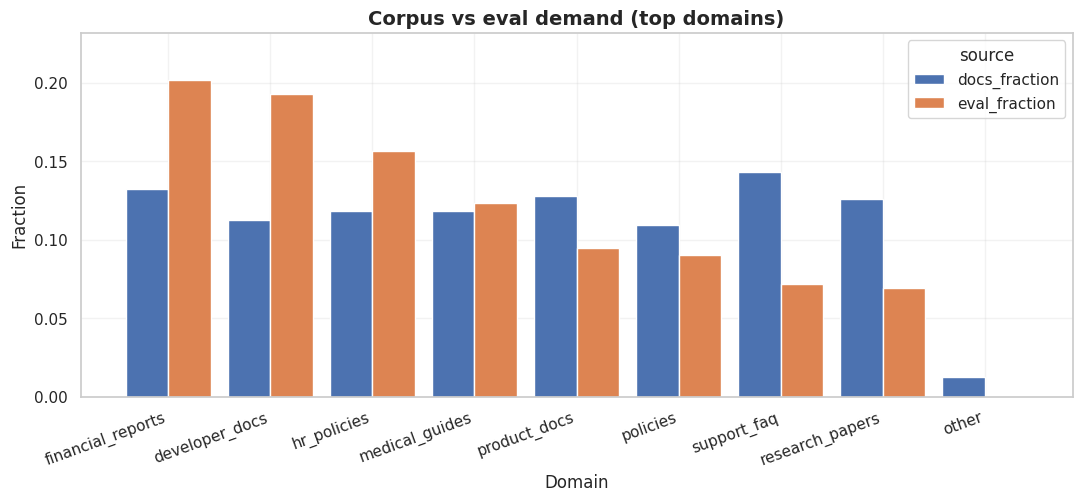

In [54]:
section("Coverage vs demand", "Compare corpus distribution to evaluation demand (top domains + other).")

TOP_N = 8
EPS = 1e-12

if ("domain" in docs.columns) and ("domain" in eval_runs.columns):
    doc_domain = docs["domain"].value_counts(normalize=True).rename("docs_fraction")
    run_domain = eval_runs["domain"].value_counts(normalize=True).rename("eval_fraction")

    dom = (
        pd.concat([doc_domain, run_domain], axis=1)
        .fillna(0.0)
        .reset_index()
        .rename(columns={"index": "domain"})
    )

    dom = dom[(dom["docs_fraction"] > EPS) | (dom["eval_fraction"] > EPS)].copy()
    dom = dom.sort_values("eval_fraction", ascending=False).reset_index(drop=True)

    top = dom.head(TOP_N).copy()
    rest = dom.iloc[TOP_N:].copy()

    if len(rest):
        other = pd.DataFrame([{
            "domain": "other",
            "docs_fraction": float(rest["docs_fraction"].sum()),
            "eval_fraction": float(rest["eval_fraction"].sum()),
        }])
        dom_plot = pd.concat([top, other], ignore_index=True)
    else:
        dom_plot = top

    display(style_table(dom_plot, max_rows=25, center_cols=["docs_fraction", "eval_fraction"]))

    x = np.arange(len(dom_plot))
    w = 0.42

    plt.figure(figsize=(11.0, 5.2))
    plt.bar(x - w/2, dom_plot["docs_fraction"].values, width=w, label="docs_fraction")
    plt.bar(x + w/2, dom_plot["eval_fraction"].values, width=w, label="eval_fraction")

    plt.xticks(x, dom_plot["domain"].astype(str).values, rotation=20, ha="right")
    ymax = float(max(dom_plot["docs_fraction"].max(), dom_plot["eval_fraction"].max()))
    plt.ylim(0, ymax * 1.15 if ymax > 0 else 1.0)

    plt.ylabel("Fraction")
    plt.xlabel("Domain")
    plt.title("Corpus vs eval demand (top domains)")
    plt.legend(title="source")
    plt.tight_layout()
    plt.show()
else:
    callout("warn", "Coverage vs demand", "Column 'domain' missing in documents and/or eval_runs.")


difficulty,scenario_type,n_scenarios
easy,standard_qa,18
easy,no_answer_probe,2
hard,standard_qa,18
hard,no_answer_probe,3
medium,standard_qa,18
medium,no_answer_probe,3


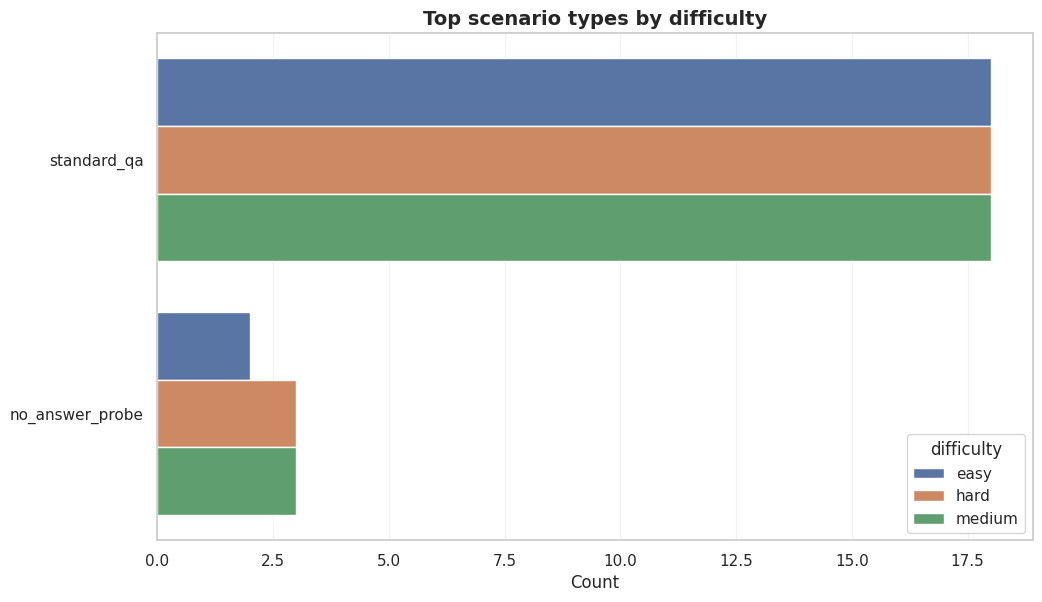

In [55]:

section("Scenario landscape", "Scenario types and difficulty (when columns exist).")

scn = scenarios.copy()
if "difficulty_level" in scn.columns and "difficulty" not in scn.columns:
    scn = scn.rename(columns={"difficulty_level":"difficulty"})

need = {"scenario_type","difficulty"}
if need.issubset(scn.columns):
    scen_summary = scn.groupby(["difficulty","scenario_type"])["scenario_id"].count().rename("n_scenarios").reset_index()
    scen_summary = scen_summary.sort_values(["difficulty","n_scenarios"], ascending=[True, False])
    display(style_table(scen_summary, max_rows=30))

    top_types = scen_summary.groupby("scenario_type")["n_scenarios"].sum().sort_values(ascending=False).head(12).index
    plt.figure(figsize=(10.6, 6.2))
    sns.countplot(data=scn[scn["scenario_type"].isin(top_types)], y="scenario_type", hue="difficulty", order=top_types)
    plt.title("Top scenario types by difficulty")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    callout("warn", "Skipped", "Missing 'scenario_type' and/or 'difficulty' in scenarios.")


In [56]:

section("Example drill-downs", "Query → retrieved chunks (top-k) → outcome.")

def pick_example(df: pd.DataFrame, correct: Optional[int] = None, hallucinated: Optional[int] = None) -> pd.Series:
    x = df.copy()
    if correct is not None and "is_correct" in x.columns:
        x = x[to_num(x["is_correct"]) == int(correct)]
    if hallucinated is not None and "hallucination_flag" in x.columns:
        x = x[to_num(x["hallucination_flag"]) == int(hallucinated)]
    if len(x) == 0:
        x = df
    return x.sample(1, random_state=RANDOM_STATE).iloc[0]

def show_run(row: pd.Series) -> None:
    run_id = row.get("run_id", None)

    cols = [c for c in ["run_id","example_id","domain","task_type","difficulty","scenario_id","query","gold_answer","is_correct","hallucination_flag","recall_at_10","mrr_at_10","total_latency_ms","total_cost_usd"] if c in eval_runs.columns]
    view = eval_runs.loc[eval_runs["run_id"] == run_id, cols].head(1).copy() if ("run_id" in eval_runs.columns and run_id is not None) else pd.DataFrame([row[cols]])

    if "query" in view.columns:
        view["query"] = view["query"].map(lambda x: clip_text(x, 260))
    if "gold_answer" in view.columns:
        view["gold_answer"] = view["gold_answer"].map(lambda x: clip_text(x, 260))
    display(style_table(view, max_rows=1, wrap_cols=["query","gold_answer"], max_width_px={"query": 720, "gold_answer": 720}))

    if retrieval is None or run_id is None or "run_id" not in retrieval.columns:
        return

    sub = retrieval[retrieval["run_id"] == run_id].copy()
    if len(sub) == 0:
        return

    if "rank" in sub.columns:
        sub = sub.sort_values("rank")
    elif "retrieval_score" in sub.columns:
        sub = sub.sort_values("retrieval_score", ascending=False)
    sub = sub.head(TOP_K_CHUNKS_TO_SHOW)

    if "chunk_id" in sub.columns and "chunk_id" in chunks.columns:
        sub = sub.merge(chunks, on="chunk_id", how="left", suffixes=("", "_chunk"))
    if "doc_id" in sub.columns and "doc_id" in docs.columns:
        doc_cols = ["doc_id"] + [c for c in ["title","domain"] if c in docs.columns]
        sub = sub.merge(docs[doc_cols], on="doc_id", how="left")

    if "chunk_text" in sub.columns:
        sub["chunk_snippet"] = sub["chunk_text"].map(lambda x: clip_text(x, 320))

    cols2 = [c for c in ["rank","chunk_id","doc_id","title","retrieval_score","is_relevant","chunk_index","estimated_tokens","chunk_snippet"] if c in sub.columns]
    display(style_table(sub[cols2], max_rows=TOP_K_CHUNKS_TO_SHOW, wrap_cols=["chunk_snippet"], max_width_px={"chunk_snippet": 720}))

row_ok = pick_example(eval_runs, correct=1, hallucinated=0)
callout("good", "Example", "Correct (sample).")
show_run(row_ok)

row_bad = pick_example(eval_runs, correct=0, hallucinated=1)
callout("bad", "Example", "Incorrect + hallucination (sample, when available).")
show_run(row_bad)


run_id,example_id,domain,task_type,difficulty,scenario_id,query,gold_answer,is_correct,hallucination_flag,recall_at_10,mrr_at_10,total_latency_ms,total_cost_usd
run_2258,QA002259,support_faq,summarization,medium,SC0061,Where can I check the status of my support ticket?,Ticket status is available on the support portal under 'My Requests'.,1,0,1.000000,1.000000,794,0.000091


rank,chunk_id,doc_id,title,retrieval_score,is_relevant,chunk_index,estimated_tokens,chunk_snippet
1,C01014,DOC0129,Support playbook: handling issue and reset tickets (2020),0.758587,1,19,93,"Below are a few paragraphs from a practical troubleshooting FAQ. In this section of 'Support playbook: handling issue and reset tickets (2020)' explains how to issue when users face reset issues. It walks through the steps that agents follow in the internal help center, highlighting common failure modes and when to esc…"
2,C00084,DOC0011,"Issue and Reset support guide (EMEA, 2019)",0.766625,1,7,92,"Here are a few paragraphs from a practical troubleshooting FAQ. In this section of 'Issue and Reset support guide (EMEA, 2019)' explains how to ticket when users face troubleshooting issues. It walks through the steps that agents follow in the internal help center, highlighting common failure modes and when to escalate…"
3,C00104,DOC0014,"Troubleshooting and Issue support guide (AMER, 2019)",0.651113,1,2,91,"Here are a few paragraphs from a practical troubleshooting FAQ. This part of 'Troubleshooting and Issue support guide (AMER, 2019)' explains how to troubleshooting when users face steps issues. It walks through the steps that agents follow in the internal help center, highlighting common failure modes and when to escal…"
4,C04901,DOC0615,"How to ticket — internal support article (Global, 2021)",0.392249,0,11,95,"This excerpt gathers a few paragraphs from a practical troubleshooting FAQ. In this section of 'How to ticket — internal support article (Global, 2021)' explains how to issue when users face ticket issues. It walks through the steps that agents follow in the internal help center, highlighting common failure modes and w…"
5,C01119,DOC0143,"How to reset — internal support article (APAC, 2019)",0.564585,1,0,96,"Here is a mid-section excerpt from a customer support knowledge base article. This opening section of 'How to reset — internal support article (APAC, 2019)' explains how to ticket when users face steps issues. It walks through the steps that agents follow in the internal help center, highlighting common failure modes a…"


run_id,example_id,domain,task_type,difficulty,scenario_id,query,gold_answer,is_correct,hallucination_flag,recall_at_10,mrr_at_10,total_latency_ms,total_cost_usd
run_2097,QA002098,developer_docs,comparison,hard,SC0003,How do I authenticate using API keys?,API keys are passed as a bearer token in the Authorization header.,0,1,1.000000,0.166667,627,0.000141


rank,chunk_id,doc_id,title,retrieval_score,is_relevant,chunk_index,estimated_tokens,chunk_snippet
1,C03290,DOC0410,Service-to-service auth and endpoint — engineering guide 2024,0.339959,0,8,83,"This portion is taken from developer documentation used by engineering teams. In this section of 'Service-to-service auth and endpoint — engineering guide 2024' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, request and response shapes, and how to handle authenticati…"
2,C03234,DOC0406,Developer integration guide — Request and Api,0.446808,0,2,80,"This passage comes from developer documentation used by engineering teams. This part of 'Developer integration guide — Request and Api' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, request and response shapes, and how to handle request safely in production. Code sn…"
3,C03256,DOC0406,Developer integration guide — Request and Api,0.757425,0,24,82,"This chunk contains part of a developer-facing guide or API reference. In this section of 'Developer integration guide — Request and Api' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, request and response shapes, and how to handle api safely in production. Code snip…"
4,C03295,DOC0410,Service-to-service auth and endpoint — engineering guide 2024,0.784004,0,13,83,"This chunk contains part of a developer-facing guide or API reference. In this section of 'Service-to-service auth and endpoint — engineering guide 2024' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, request and response shapes, and how to handle api safely in produ…"
5,C04775,DOC0600,Developer integration guide — Endpoint and Response,0.334509,0,0,82,"The following section comes from developer documentation used by engineering teams. This opening section of 'Developer integration guide — Endpoint and Response' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, request and response shapes, and how to handle request saf…"


domain,scenario_type,difficulty,n_rows,correct_rate
financial_reports,standard_qa,unknown,768,0.713542
hr_policies,standard_qa,unknown,595,0.729412
research_papers,standard_qa,unknown,261,0.743295
product_docs,standard_qa,unknown,359,0.746518
developer_docs,standard_qa,unknown,734,0.747956
policies,standard_qa,unknown,343,0.755102
medical_guides,standard_qa,unknown,468,0.786325
support_faq,standard_qa,unknown,272,0.797794


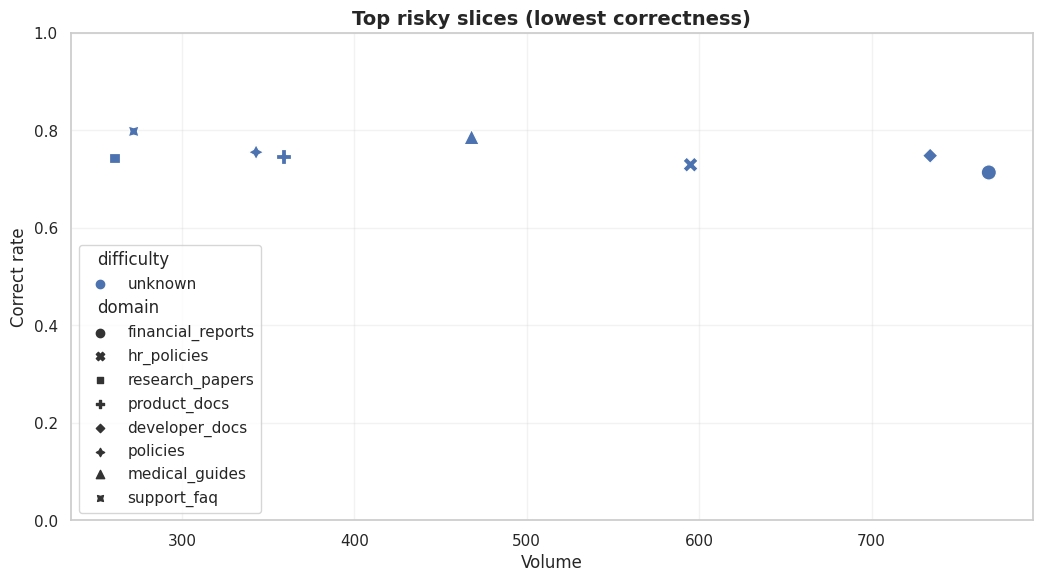

In [57]:

section("Scenario risk slices", "High-volume slices with low correctness (labeled subset).")

if "is_correct" in eval_runs.columns:
    labeled = eval_runs.copy()
    labeled["is_correct"] = to_num(labeled["is_correct"])
    labeled = labeled.dropna(subset=["is_correct"]).copy()
else:
    labeled = pd.DataFrame()

scn = scenarios.copy()
if "difficulty_level" in scn.columns and "difficulty" not in scn.columns:
    scn = scn.rename(columns={"difficulty_level":"difficulty"})

need_runs = {"domain","scenario_id","is_correct"}
need_scn = {"scenario_id","scenario_type"}
if need_runs.issubset(labeled.columns) and need_scn.issubset(scn.columns):
    cols_scn = ["scenario_id","scenario_type"] + (["difficulty"] if "difficulty" in scn.columns else [])
    m = labeled.merge(scn[cols_scn], on="scenario_id", how="left")

    m["domain"] = m["domain"].fillna("unknown")
    m["scenario_type"] = m["scenario_type"].fillna("unknown")
    m["difficulty"] = m["difficulty"].fillna("unknown") if "difficulty" in m.columns else "unknown"

    id_col = "example_id" if "example_id" in m.columns else ("run_id" if "run_id" in m.columns else "scenario_id")

    tbl = (
        m.groupby(["domain","scenario_type","difficulty"], dropna=False)
        .agg(n_rows=(id_col,"size"), correct_rate=("is_correct","mean"))
        .reset_index()
    )
    tbl = tbl[tbl["n_rows"] >= MIN_SEGMENT_N].copy()
    tbl = tbl.sort_values(["correct_rate","n_rows"], ascending=[True, False]).reset_index(drop=True)
    display(style_table(tbl.head(30), max_rows=30, center_cols=["n_rows","correct_rate"]))

    top = tbl.head(20).copy()
    plt.figure(figsize=(10.6, 6.0))
    sns.scatterplot(data=top, x="n_rows", y="correct_rate", hue="difficulty", style="domain", s=120)
    plt.title("Top risky slices (lowest correctness)")
    plt.xlabel("Volume")
    plt.ylabel("Correct rate")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    callout("warn", "Skipped", "Need labeled is_correct + scenario metadata.")


retrieval_strategy,generator_model,difficulty,n_rows,correct_rate,hallucination_rate,avg_latency_ms,avg_cost_usd,score
bm25_then_rerank,gpt-4o-mini,easy,53,0.962264,0.000000,685.169811,0.000157,0.619632
hybrid,gpt-4o-mini,easy,47,0.914894,0.042553,655.425532,0.000147,0.561605
dense_then_rerank,gpt-4o-mini,easy,53,0.924528,0.037736,687.301887,0.000160,0.558188
bm25_then_rerank,llama-3.1-8b-instruct,easy,34,0.911765,0.058824,785.205882,0.000070,0.483847
bm25,gpt-4o-mini,easy,37,0.810811,0.027027,637.594595,0.000143,0.475754
hybrid,gpt-4o,easy,31,0.935484,0.000000,999.774194,0.001902,0.435026
dense,gpt-4o-mini,easy,38,0.815789,0.105263,668.368421,0.000148,0.418403
dense,gpt-4o-mini,medium,173,0.809249,0.144509,690.849711,0.000153,0.377072
bm25,llama-3.1-8b-instruct,easy,31,0.806452,0.129032,748.774194,0.000065,0.354626
bm25_then_rerank,gpt-4o-mini,medium,164,0.780488,0.189024,663.134146,0.000146,0.335462


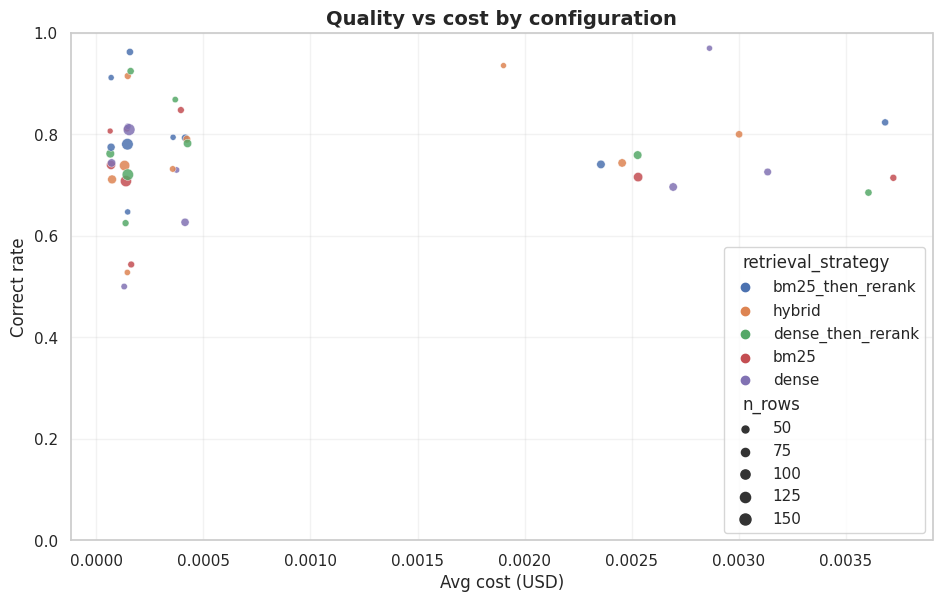

In [58]:

section("Configuration comparison", "Compare settings under quality × cost × latency constraints.")

group_cols = [c for c in ["retrieval_strategy","generator_model","difficulty"] if c in eval_runs.columns]
if group_cols:
    df = eval_runs.copy()
    for c in ["is_correct","hallucination_flag","total_latency_ms","total_cost_usd"]:
        if c in df.columns:
            df[c] = to_num(df[c])

    agg = df.groupby(group_cols, dropna=False).agg(
        n_rows=("run_id","size") if "run_id" in df.columns else (group_cols[0],"size"),
        correct_rate=("is_correct","mean") if "is_correct" in df.columns else (group_cols[0],"size"),
        hallucination_rate=("hallucination_flag","mean") if "hallucination_flag" in df.columns else (group_cols[0],"size"),
        avg_latency_ms=("total_latency_ms","mean") if "total_latency_ms" in df.columns else (group_cols[0],"size"),
        avg_cost_usd=("total_cost_usd","mean") if "total_cost_usd" in df.columns else (group_cols[0],"size"),
    ).reset_index()

    if "is_correct" in df.columns:
        agg = agg[agg["n_rows"] >= MIN_SLICE_N].copy()

    for c in ["correct_rate","hallucination_rate","avg_latency_ms","avg_cost_usd"]:
        if c not in agg.columns:
            agg[c] = np.nan

    agg["score"] = (
        agg["correct_rate"].fillna(0.0)
        - 0.6 * agg["hallucination_rate"].fillna(0.0)
        - 0.0005 * agg["avg_latency_ms"].fillna(0.0)
        - 0.30 * agg["avg_cost_usd"].fillna(0.0)
    )

    agg = agg.sort_values("score", ascending=False).reset_index(drop=True)
    display(style_table(agg.head(25), max_rows=25, center_cols=["n_rows","correct_rate","hallucination_rate","avg_latency_ms","avg_cost_usd","score"]))

    if "avg_cost_usd" in agg.columns and "correct_rate" in agg.columns and agg["avg_cost_usd"].notna().any():
        plt.figure(figsize=(9.6, 6.2))
        sns.scatterplot(data=agg, x="avg_cost_usd", y="correct_rate", hue=group_cols[0], size="n_rows", alpha=0.85)
        plt.title("Quality vs cost by configuration")
        plt.xlabel("Avg cost (USD)")
        plt.ylabel("Correct rate")
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()
else:
    callout("warn", "Skipped", "No configuration columns found.")


bucket,fraction
good_retrieval_good_answer,0.682793
good_retrieval_bad_answer,0.226726
bad_retrieval_good_answer,0.061192
bad_retrieval_bad_answer,0.029289


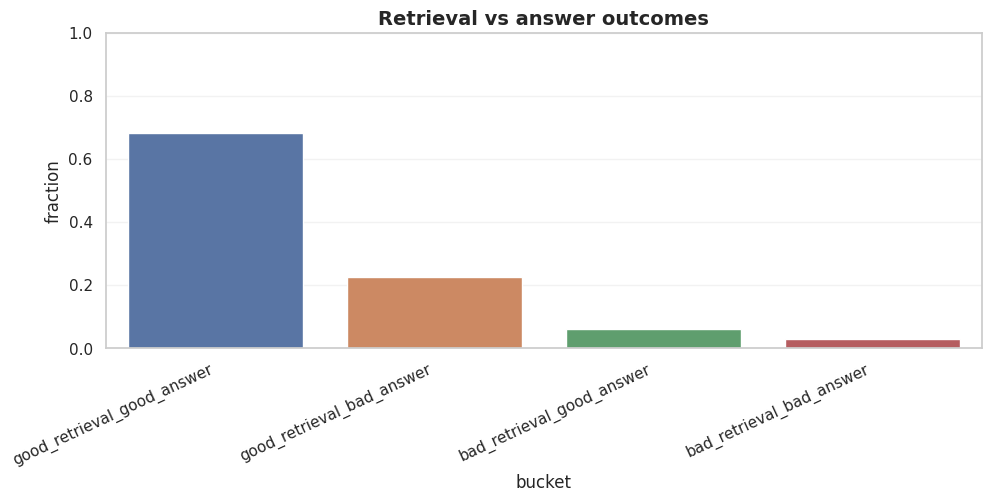

In [59]:

section("Retrieval vs generation", "Separate failure modes using recall_at_10 (labeled subset).")

src = eval_runs.copy()
if {"is_correct","recall_at_10"}.issubset(src.columns):
    src["is_correct"] = to_num(src["is_correct"])
    src["recall_at_10"] = to_num(src["recall_at_10"])
    src = src.dropna(subset=["is_correct","recall_at_10"]).copy()

    src["retrieval_ok"] = src["recall_at_10"] >= RETRIEVAL_OK_THRESHOLD
    src["gen_ok"] = src["is_correct"] == 1

    src["bucket"] = np.select(
        [
            src["retrieval_ok"] & src["gen_ok"],
            src["retrieval_ok"] & (~src["gen_ok"]),
            (~src["retrieval_ok"]) & src["gen_ok"],
            (~src["retrieval_ok"]) & (~src["gen_ok"]),
        ],
        ["good_retrieval_good_answer","good_retrieval_bad_answer","bad_retrieval_good_answer","bad_retrieval_bad_answer"],
        default="other",
    ).astype(str)

    quad = src["bucket"].value_counts(normalize=True).rename("fraction").reset_index().rename(columns={"index":"bucket"})
    display(style_table(quad, max_rows=10, center_cols=["fraction"]))

    plt.figure(figsize=(10.2, 5.2))
    sns.barplot(data=quad, x="bucket", y="fraction")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, 1)
    plt.title("Retrieval vs answer outcomes")
    plt.tight_layout()
    plt.show()
else:
    callout("warn", "Skipped", "Need is_correct + recall_at_10.")

model,roc_auc,avg_precision
LogisticRegression,0.756781,0.883900
Random baseline,0.500000,0.743985


              precision    recall  f1-score   support

           0      0.792     0.343     0.479       245
           1      0.811     0.969     0.883       711

    accuracy                          0.809       956
   macro avg      0.802     0.656     0.681       956
weighted avg      0.806     0.809     0.779       956



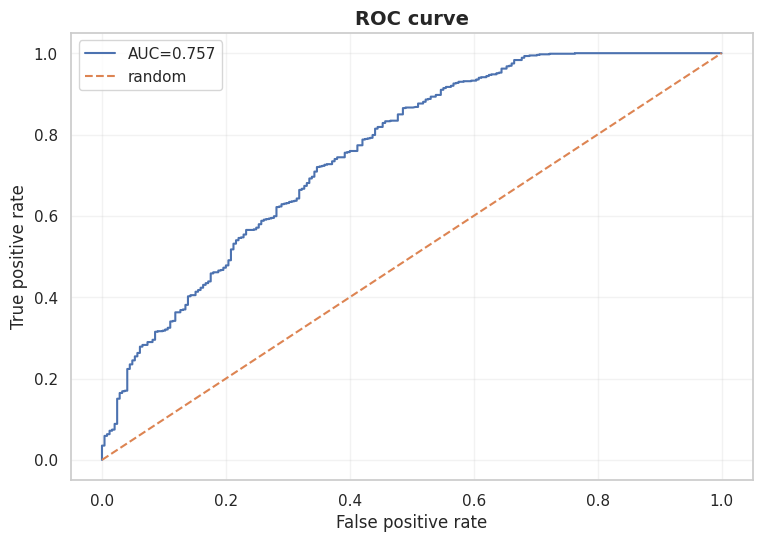

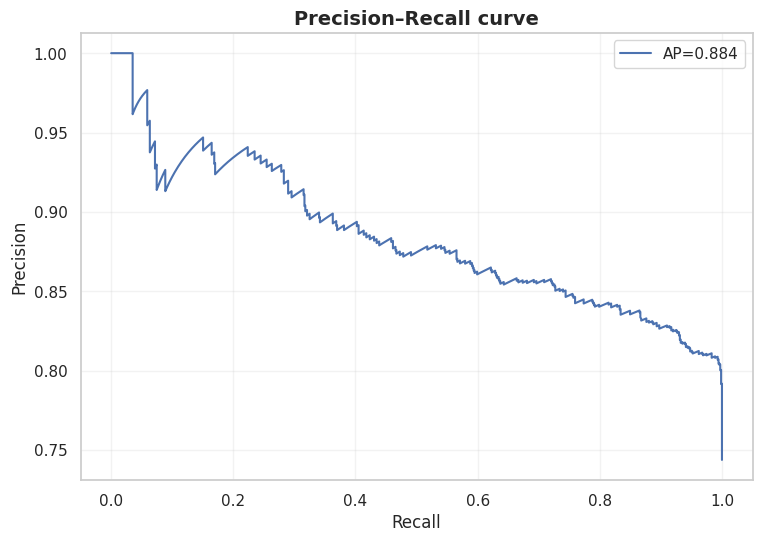

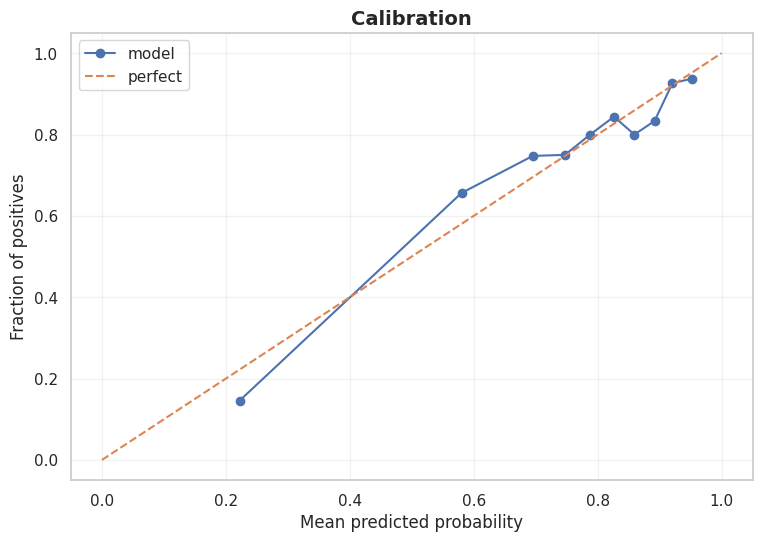

threshold,coverage,error_rate_on_shown
0.100000,0.975941,0.237942
0.200000,0.945607,0.213496
0.300000,0.930962,0.202247
0.400000,0.914226,0.192220
0.500000,0.889121,0.189412
0.600000,0.836820,0.176250
0.700000,0.743724,0.164557
0.800000,0.514644,0.138211
0.900000,0.219665,0.071429


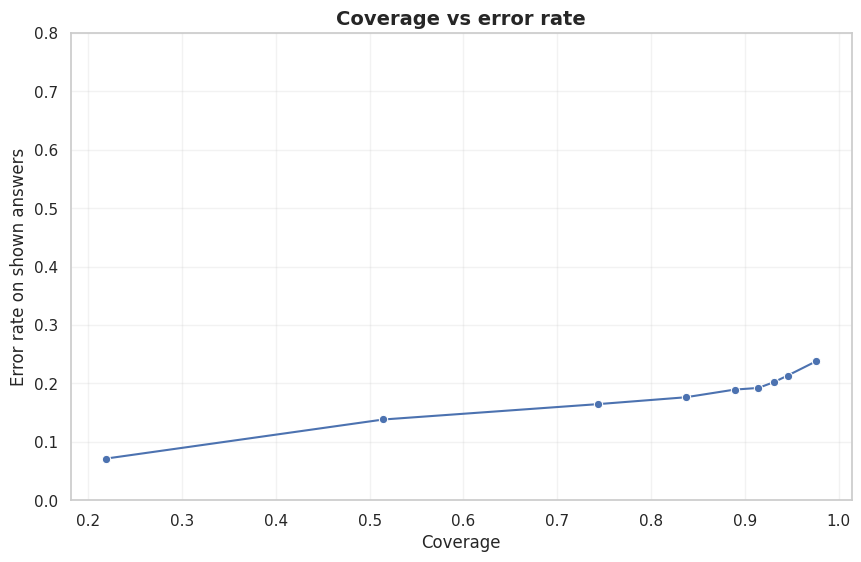

In [60]:

section("One baseline model", "LogisticRegression baseline + calibration + threshold trade-offs (labeled subset).")

target = "is_correct"
src = eval_runs.copy()
if target in src.columns:
    src[target] = to_num(src[target])
    src = src.dropna(subset=[target]).copy()
else:
    src = pd.DataFrame()

numeric_features = [c for c in [
    "n_retrieved_chunks","top1_score","mean_retrieved_score","recall_at_5","recall_at_10","mrr_at_10",
    "latency_ms_retrieval","latency_ms_generation","total_latency_ms",
    "context_window_tokens","answer_tokens","prompt_tokens","total_cost_usd",
] if c in src.columns]

categorical_features = [c for c in [
    "domain","task_type","difficulty","retrieval_strategy","chunking_strategy",
    "embedding_model","reranker_model","generator_model","eval_mode",
] if c in src.columns]

feature_cols = numeric_features + categorical_features

if len(src) and len(feature_cols) and src[target].nunique() >= 2:
    X = src[feature_cols].copy()
    for c in numeric_features:
        X[c] = to_num(X[c]).replace([np.inf,-np.inf], np.nan)

    y = src[target].astype(int)
    base_rate = float(y.mean())

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None,
    )

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

    transformers = []
    if numeric_features:
        transformers.append(("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features))
    if categorical_features:
        transformers.append(("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", ohe)]), categorical_features))

    pre = ColumnTransformer(transformers=transformers)
    model = Pipeline([("prep", pre), ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])

    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)

    res = pd.DataFrame([
        {"model":"LogisticRegression", "roc_auc": roc_auc, "avg_precision": ap},
        {"model":"Random baseline", "roc_auc": 0.5, "avg_precision": base_rate},
    ])
    display(style_table(res, max_rows=10, center_cols=["roc_auc","avg_precision"]))

    print(classification_report(y_test, pred, digits=3))

    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.figure(figsize=(7.8, 5.6))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1],"--", label="random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.figure(figsize=(7.8, 5.6))
    plt.plot(rec, prec, label=f"AP={ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    plt.figure(figsize=(7.8, 5.6))
    plt.plot(mean_pred, frac_pos, marker="o", label="model")
    plt.plot([0,1],[0,1],"--", label="perfect")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title("Calibration")
    plt.legend()
    plt.tight_layout()
    plt.show()

    rows = []
    for thr in THRESHOLDS:
        m = proba >= thr
        coverage = float(m.mean())
        err = float(1.0 - y_test[m].mean()) if m.sum() else np.nan
        rows.append({"threshold": float(thr), "coverage": coverage, "error_rate_on_shown": err})
    th = pd.DataFrame(rows)
    display(style_table(th, max_rows=25, center_cols=["threshold","coverage","error_rate_on_shown"]))

    plt.figure(figsize=(8.8, 5.8))
    sns.lineplot(data=th, x="coverage", y="error_rate_on_shown", marker="o")
    plt.xlabel("Coverage")
    plt.ylabel("Error rate on shown answers")
    plt.title("Coverage vs error rate")
    plt.ylim(0, 0.8)
    plt.tight_layout()
    plt.show()
else:
    callout("warn", "Skipped", "Need labeled is_correct + usable features + both classes present.")


## Key takeaways

- Start with **high volume + low correctness** slices to get the most impact.
- Use **retrieval vs generation** to decide whether to expand the index / adjust retrieval, or to tighten generation / grounding.
- Use the **config trade-off view** to pick a setting that matches budget and latency constraints.
- Use the **threshold curve** to gate rollout: reduce risk by lowering coverage.
